# Momentum Rotational Portfolio — Upgraded

## What changed vs the original
| Toggle | Cell 1 variable | Default | Behaviour |
|---|---|---|---|
| Ranking method | `USE_MACDV` | `True` | `True` → MACD-V ranking · `False` → original RSI ranking |
| Position sizing | `USE_VOL_WEIGHTING` | `True` | `True` → inverse-vol sizes slots · `False` → equal weight |

**Only cells 1, 6, 7, and 14 were modified.**
Cells 2–5 and 8–13 are identical to the original.

---
### MACD-V explained
MACD-V = MACD(fast, slow) / rolling_std(MACD line, norm_window)
Normalising by the MACD line's own historical volatility makes scores
directly comparable across assets with different price scales and vol regimes.
Eligibility threshold: MACD-V > 0 (positive normalised momentum).

### Inverse-vol sizing explained
Within the selected top-N slots, each risk asset receives weight proportional
to 1/σ (where σ = realised vol over the past VOL_WINDOW bars), then
renormalised so total risk allocation is unchanged. The safe-haven back-fill
keeps equal-weight behaviour. Only strictly past returns are used — no look-ahead.

In [395]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 1 — Configuration & Parameters
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ── Periods ───────────────────────────────────────────────────────────────────
IS_START  = '2018-01-01'
IS_END    = '2022-12-31'
OOS_START = '2023-01-01'
OOS_END   = '2025-12-31'

# ── Portfolio Parameters ──────────────────────────────────────────────────────
TOP_N          = 16
SAFE_HAVEN     = 'GLD'
REBALANCE_FREQ = 'W-FRI'
RSI_PERIOD     = 14      # only active when USE_MACDV = False
RSI_THRESHOLD  = 50      # only active when USE_MACDV = False

# ── Feature Toggles  ★ NEW ───────────────────────────────────────────────────
# USE_MACDV:
#   True  → rank by MACD-V (MACD normalised by its rolling std).
#            Eligible: MACD-V > 0. Ranked descending (rank 1 = strongest).
#   False → original RSI ranking (RSI >= RSI_THRESHOLD, ranked descending).
USE_MACDV = True

# USE_VOL_WEIGHTING:
#   True  → size selected slots by 1/σ (inverse realised vol), renormalised
#            so total risk allocation is unchanged. Safe-haven stays equal-wt.
#   False → equal weight per slot (original behaviour).
USE_VOL_WEIGHTING = False
# ── MACD-V Parameters (active when USE_MACDV = True) ─────────────────────────
MACDV_FAST = 12    # fast EMA span
MACDV_SLOW = 26    # slow EMA span
MACDV_NORM = 26    # rolling window to compute std of the MACD line

# ── Volatility Weighting Parameters (active when USE_VOL_WEIGHTING = True) ───
VOL_WINDOW = 20    # lookback bars on FULL_INDEX for realised vol
VOL_FLOOR  = 1e-6  # σ floor to prevent division by zero

# ── Transaction Cost Model ────────────────────────────────────────────────────
CRYPTO_TICKERS         = {'BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD'}
TQQQ_DECAY_BPS_PER_DAY = 0.7 / 10_000

def one_way_cost(ticker: str) -> float:
    if ticker in CRYPTO_TICKERS:
        return 0.0030
    return 0.0011

# ── Best ensemble logic per asset ─────────────────────────────────────────────
BEST_LOGIC = {
    'SMH':     ('OR',       'AND'),
    'GDX':     ('OR',       'OR'),
    'DGRW':    ('AND',      'OR'),
    'DXJ':     ('OR',       'OR'),
    'BOTZ':    ('AND',      'OR'),
    'LIT':     ('AND',      'OR'),
    'URNM':    ('OR',       'OR'),
    'ARKK':    ('AND',      'OR'),
    'ARKG':    ('OR',       'OR'),
    'HACK':    ('AND',      'OR'),
    'BLOK':    ('OR',       'OR'),
    'QTUM':    ('AND',      'OR'),
    'AIRR':    ('OR',       'OR'),
    'IRBO':    ('OR',       'OR'),
    'MTUM':    ('OR',       'AND'),
    'DBMF':    ('OR',       'AND'),
    'KMLM':    ('AND',      'OR'),
    'GLD':     ('AND',      'OR'),
    'SPY':     ('OR',       'AND'),
    'QQQ':     ('AND',      'OR'),
    'TQQQ':    ('AND',      'AND'),
    'BTC-USD': ('AND',      'OR'),
    'SOL-USD': ('AND',      'AND'),
    'ETH-USD': ('AND',      'OR'),
    'BNB-USD': ('OR',       'OR'),
    'MSFT':    ('OR',       'AND'),
    'AAPL':    ('OR',       'OR'),
    'NVDA':    ('OR',       'OR'),
}

TICKERS = list(BEST_LOGIC.keys())

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

print('Parameters defined ✓')
print(f'Universe : {TICKERS}')
print(f'TOP_N={TOP_N}  SAFE_HAVEN={SAFE_HAVEN}  RSI_PERIOD={RSI_PERIOD}  RSI_THRESHOLD={RSI_THRESHOLD}')
print(f'\nFeature toggles:')
print(f'  USE_MACDV         = {USE_MACDV}')
print(f'  USE_VOL_WEIGHTING = {USE_VOL_WEIGHTING}')
if USE_MACDV:
    print(f'  MACD-V  : fast={MACDV_FAST}, slow={MACDV_SLOW}, norm_window={MACDV_NORM}')
else:
    print(f'  RSI     : period={RSI_PERIOD}, threshold={RSI_THRESHOLD}')
if USE_VOL_WEIGHTING:
    print(f'  Vol-wt  : window={VOL_WINDOW}, floor={VOL_FLOOR}')
print('\nTransaction cost model:')
for t in TICKERS:
    note = ' + 0.7 bp/day holding decay' if t == 'TQQQ' else ''
    print(f'  {t:<10}: {one_way_cost(t)*10_000:.0f} bps one-way{note}')

Parameters defined ✓
Universe : ['SMH', 'GDX', 'DGRW', 'DXJ', 'BOTZ', 'LIT', 'URNM', 'ARKK', 'ARKG', 'HACK', 'BLOK', 'QTUM', 'AIRR', 'IRBO', 'MTUM', 'DBMF', 'KMLM', 'GLD', 'SPY', 'QQQ', 'TQQQ', 'BTC-USD', 'SOL-USD', 'ETH-USD', 'BNB-USD', 'MSFT', 'AAPL', 'NVDA']
TOP_N=16  SAFE_HAVEN=GLD  RSI_PERIOD=14  RSI_THRESHOLD=50

Feature toggles:
  USE_MACDV         = True
  USE_VOL_WEIGHTING = False
  MACD-V  : fast=12, slow=26, norm_window=26

Transaction cost model:
  SMH       : 11 bps one-way
  GDX       : 11 bps one-way
  DGRW      : 11 bps one-way
  DXJ       : 11 bps one-way
  BOTZ      : 11 bps one-way
  LIT       : 11 bps one-way
  URNM      : 11 bps one-way
  ARKK      : 11 bps one-way
  ARKG      : 11 bps one-way
  HACK      : 11 bps one-way
  BLOK      : 11 bps one-way
  QTUM      : 11 bps one-way
  AIRR      : 11 bps one-way
  IRBO      : 11 bps one-way
  MTUM      : 11 bps one-way
  DBMF      : 11 bps one-way
  KMLM      : 11 bps one-way
  GLD       : 11 bps one-way
  SPY       : 1

In [396]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 2 — Data Download & Calendar Construction
# ════════════════════════════════════════════════════════════════════════════
# OPTION C: merged full calendar.
# FULL_INDEX = union of every trading day across all equity AND crypto tickers.
# Equity closes are ffill'd over weekends → pct_change() = 0 on those days
# (correct: markets closed, no phantom P&L).
# Crypto closes are real every day → weekend P&L is captured correctly.
# ════════════════════════════════════════════════════════════════════════════

raw = yf.download(TICKERS, start='2017-01-01', end=OOS_END, auto_adjust=True)

price_data = {}
for ticker in TICKERS:
    try:
        df = pd.DataFrame({
            'Open':   raw['Open'][ticker],
            'High':   raw['High'][ticker],
            'Low':    raw['Low'][ticker],
            'Close':  raw['Close'][ticker],
            'Volume': raw['Volume'][ticker],
        }).dropna()
        price_data[ticker] = df
        print(f'  {ticker}: {len(df)} bars  ({df.index[0].date()} → {df.index[-1].date()})')
    except Exception as e:
        print(f'  {ticker}: FAILED — {e}')

print(f'\nLoaded {len(price_data)} tickers ✓')

# Build merged full calendar: union of all native indices
all_native_indices = [df.index for df in price_data.values()]
FULL_INDEX = all_native_indices[0]
for idx in all_native_indices[1:]:
    FULL_INDEX = FULL_INDEX.union(idx)
FULL_INDEX = FULL_INDEX.sort_values()

# Equity-only union for diagnostics
equity_tickers_list = [t for t in TICKERS if t not in CRYPTO_TICKERS and t in price_data]
_equity_union = price_data[equity_tickers_list[0]].index
for t in equity_tickers_list[1:]:
    _equity_union = _equity_union.union(price_data[t].index)
EQUITY_TRADING_DAYS = _equity_union.sort_values()

print(f'\nFULL_INDEX  : {len(FULL_INDEX)} days  '
      f'({FULL_INDEX[0].date()} → {FULL_INDEX[-1].date()})')
print(f'Equity days : {len(EQUITY_TRADING_DAYS)} days')
print(f'Extra crypto days (weekends/holidays): '
      f'{len(FULL_INDEX) - len(EQUITY_TRADING_DAYS)}')

[*********************100%***********************]  28 of 28 completed


  SMH: 2261 bars  (2017-01-03 → 2025-12-30)
  GDX: 2261 bars  (2017-01-03 → 2025-12-30)
  DGRW: 2261 bars  (2017-01-03 → 2025-12-30)
  DXJ: 2261 bars  (2017-01-03 → 2025-12-30)
  BOTZ: 2261 bars  (2017-01-03 → 2025-12-30)
  LIT: 2261 bars  (2017-01-03 → 2025-12-30)
  URNM: 1526 bars  (2019-12-04 → 2025-12-30)
  ARKK: 2261 bars  (2017-01-03 → 2025-12-30)
  ARKG: 2261 bars  (2017-01-03 → 2025-12-30)
  HACK: 2261 bars  (2017-01-03 → 2025-12-30)
  BLOK: 1994 bars  (2018-01-25 → 2025-12-30)
  QTUM: 1840 bars  (2018-09-05 → 2025-12-30)
  AIRR: 2261 bars  (2017-01-03 → 2025-12-30)
  IRBO: 1888 bars  (2018-06-26 → 2025-12-30)
  MTUM: 2261 bars  (2017-01-03 → 2025-12-30)
  DBMF: 1672 bars  (2019-05-08 → 2025-12-30)
  KMLM: 1275 bars  (2020-12-02 → 2025-12-30)
  GLD: 2261 bars  (2017-01-03 → 2025-12-30)
  SPY: 2261 bars  (2017-01-03 → 2025-12-30)
  QQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  TQQQ: 2261 bars  (2017-01-03 → 2025-12-30)
  BTC-USD: 3286 bars  (2017-01-01 → 2025-12-30)
  SOL-USD: 209

In [397]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 3 — Indicator Library
# ════════════════════════════════════════════════════════════════════════════
# All price-based entry/exit signal functions.
# Every function applies .shift(1) as its FINAL operation — signals are
# based on yesterday's close, zero look-ahead by construction.
# Indicators are computed on each asset's native price series.
# ════════════════════════════════════════════════════════════════════════════

def compute_atr(high, low, close, period):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    atr = np.full(len(tr), np.nan)
    atr[period - 1] = tr.iloc[:period].mean()
    alpha = 1.0 / period
    for i in range(period, len(tr)):
        atr[i] = atr[i-1] * (1 - alpha) + tr.iloc[i] * alpha
    return pd.Series(atr, index=close.index)


def supertrend_signal(high, low, close, atr_period, multiplier):
    hl2 = (high + low) / 2.0
    atr = compute_atr(high, low, close, atr_period)
    basic_upper = hl2 + multiplier * atr
    basic_lower = hl2 - multiplier * atr
    n  = len(close)
    fu = np.full(n, np.nan)
    fl = np.full(n, np.nan)
    direction = np.full(n, np.nan)
    c  = close.values
    bu = basic_upper.values
    bl = basic_lower.values
    seed = atr_period
    fu[seed] = bu[seed]
    fl[seed] = bl[seed]
    direction[seed] = 1 if c[seed] > bu[seed] else -1
    for i in range(seed + 1, n):
        if np.isnan(bu[i]):
            continue
        fu[i] = bu[i] if (bu[i] < fu[i-1] or c[i-1] > fu[i-1]) else fu[i-1]
        fl[i] = bl[i] if (bl[i] > fl[i-1] or c[i-1] < fl[i-1]) else fl[i-1]
        if   c[i] > fu[i-1]: direction[i] =  1
        elif c[i] < fl[i-1]: direction[i] = -1
        else:                 direction[i] = direction[i-1]
    raw_signal = (pd.Series(direction, index=close.index) == 1).astype(int)
    return raw_signal.shift(1).fillna(0).astype(int)


def kama_signal(close, er_period, fast_period, slow_period):
    fast_sc = 2 / (fast_period + 1)
    slow_sc = 2 / (slow_period + 1)
    c = close.values
    n = len(c)
    kama = np.full(n, np.nan)
    kama[er_period - 1] = c[er_period - 1]
    for i in range(er_period, n):
        direction_  = abs(c[i] - c[i - er_period])
        volatility  = np.sum(np.abs(np.diff(c[i - er_period: i + 1])))
        er = direction_ / volatility if volatility != 0 else 0
        sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
        kama[i] = kama[i-1] + sc * (c[i] - kama[i-1])
    kama_s   = pd.Series(kama, index=close.index)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, n):
        if pd.isna(kama_s.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i] > kama_s.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < kama_s.iloc[i-1]: state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def rsi_window_signal(close, rsi_period, window):
    delta    = close.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/rsi_period, min_periods=rsi_period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    rsi      = 100 - (100 / (1 + rs))
    upper    = rsi.rolling(window).quantile(0.80)
    lower    = rsi.rolling(window).quantile(0.20)
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(rsi)):
        up = upper.iloc[i-1]
        lo = lower.iloc[i-1]
        if pd.isna(up) or pd.isna(lo):
            position.iloc[i] = state
            continue
        if state == 0:
            if rsi.iloc[i] > up: state = 1
        else:
            if rsi.iloc[i] < lo: state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def triple_ema_signal(close, fast, medium, slow):
    ef = close.ewm(span=fast,   adjust=False).mean()
    em = close.ewm(span=medium, adjust=False).mean()
    es = close.ewm(span=slow,   adjust=False).mean()
    bullish = ((ef > em) & (em > es)).astype(int)
    return bullish.shift(1).fillna(0).astype(int)


def macd_signal(close, fast, slow, signal):
    ema_fast    = close.ewm(span=fast,   adjust=False).mean()
    ema_slow    = close.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    raw = (macd_line > signal_line).astype(int)
    return raw.shift(1).fillna(0).astype(int)


def donchian_signal(close, high, low, entry_period, exit_period):
    upper_entry = high.rolling(entry_period).max()
    lower_exit  = low.rolling(exit_period).min()
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if state == 0:
            if close.iloc[i] > upper_entry.iloc[i-1]: state = 1
        else:
            if close.iloc[i] < lower_exit.iloc[i-1]:  state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


def bollinger_signal(close, period, mult):
    middle = close.rolling(window=period).mean()
    std    = close.rolling(window=period).std(ddof=0)
    lower  = middle - mult * std
    position = pd.Series(0, index=close.index, dtype=int)
    state = 0
    for i in range(1, len(close)):
        if pd.isna(lower.iloc[i-1]):
            continue
        if state == 0:
            if close.iloc[i-1] > lower.iloc[i-1] and close.iloc[i] <= lower.iloc[i]:
                state = 1
        else:
            if close.iloc[i-1] < middle.iloc[i-1] and close.iloc[i] >= middle.iloc[i]:
                state = 0
        position.iloc[i] = state
    return position.shift(1).fillna(0).astype(int)


print('Indicator library defined ✓  (all signals end with .shift(1))')

Indicator library defined ✓  (all signals end with .shift(1))


In [398]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 4 — Signal Configs & Ensemble Engine
# ════════════════════════════════════════════════════════════════════════════


def build_signals(ticker, df):
    c, h, l = df['Close'], df['High'], df['Low']
    configs = {
        'SMH':     [('3EMA(10,56,120)',   lambda: triple_ema_signal(c, 10, 56, 120)),
                    ('KAMA(27,18,24)',    lambda: kama_signal(c, 27, 18, 24))],
        'GDX':     [('KAMA(18,10,18)',    lambda: kama_signal(c, 18, 10, 18)),
                    ('3EMA(10,56,120)',   lambda: triple_ema_signal(c, 10, 56, 120))],
        'DGRW':    [('KAMA(21,4,10)',     lambda: kama_signal(c, 21, 4, 10)),
                    ('3EMA(10,64,132)',   lambda: triple_ema_signal(c, 10, 64, 132))],
        'DXJ':     [('3EMA(5,104,120)',   lambda: triple_ema_signal(c, 5, 104, 120)),
                    ('KAMA(25,32,38)',    lambda: kama_signal(c, 25, 32, 38))],
        'BOTZ':    [('MACD(5,218,77)',    lambda: macd_signal(c, 5, 218, 77)),
                    ('KAMA(15,4,60)',     lambda: kama_signal(c, 15, 4, 60))],
        'LIT':     [('MACD(9,94,43)',     lambda: macd_signal(c, 9, 94, 43)),
                    ('KAMA(6,4,12)',      lambda: kama_signal(c, 6, 4, 12))],
        'URNM':    [('KAMA(4,6,12)',      lambda: kama_signal(c, 4, 6, 12)),
                    ('MACD(5,220,47)',    lambda: macd_signal(c, 5, 220, 47))],
        'ARKK':    [('MACD(15,154,115)', lambda: macd_signal(c, 15, 154, 115)),
                    ('KAMA(27,4,22)',     lambda: kama_signal(c, 27, 4, 22))],
        'ARKG':    [('KAMA(21,4,14)',     lambda: kama_signal(c, 21, 4, 14)),
                    ('3EMA(5,48,240)',    lambda: triple_ema_signal(c, 5, 48, 240))],
        'HACK':    [('KAMA(2,6,16)',      lambda: kama_signal(c, 2, 6, 16)),
                    ('3EMA(5,56,228)',    lambda: triple_ema_signal(c, 5, 56, 228))],
        'BLOK':    [('MACD(5,210,187)',   lambda: macd_signal(c, 5, 210, 187)),
                    ('KAMA(4,4,16)',      lambda: kama_signal(c, 4, 4, 16))],
        'QTUM':    [('MACD(5,130,35)',    lambda: macd_signal(c, 5, 130, 35)),
                    ('3EMA(5,40,156)',    lambda: triple_ema_signal(c, 5, 40, 156))],
        'AIRR':    [('MACD(11,194,73)',   lambda: macd_signal(c, 11, 194, 73)),
                    ('KAMA(8,4,28)',      lambda: kama_signal(c, 8, 4, 28))],
        'IRBO':    [('MACD(5,108,35)',    lambda: macd_signal(c, 5, 108, 35)),
                    ('KAMA(3,4,18)',      lambda: kama_signal(c, 3, 4, 18))],
        'MTUM':    [('MACD(9,122,39)',    lambda: macd_signal(c, 9, 122, 39)),
                    ('3EMA(5,128,240)',   lambda: triple_ema_signal(c, 5, 128, 240))],
        'DBMF':    [('MACD(11,228,41)',   lambda: macd_signal(c, 11, 228, 41)),
                    ('3EMA(10,40,240)',   lambda: triple_ema_signal(c, 10, 40, 240))],
        'KMLM':    [('MACD(5,68,53)',     lambda: macd_signal(c, 5, 68, 53)),
                    ('3EMA(5,40,132)',    lambda: triple_ema_signal(c, 5, 40, 132))],
        'GLD':     [('MACD(53,80,51)',    lambda: macd_signal(c, 53, 80, 51)),
                    ('3EMA(15,88,120)',   lambda: triple_ema_signal(c, 15, 88, 120))],
        'SPY':     [('3EMA(5,88,192)',    lambda: triple_ema_signal(c, 5, 88, 192)),
                    ('MACD(9,94,39)',     lambda: macd_signal(c, 9, 94, 39))],
        'QQQ':     [('KAMA(11,12,20)',    lambda: kama_signal(c, 11, 12, 20)),
                    ('MACD(7,226,37)',    lambda: macd_signal(c, 7, 226, 37))],
        'TQQQ':    [('MACD(7,62,47)',     lambda: macd_signal(c, 7, 62, 47))],
        'BTC-USD': [('MACD(5,58,39)',     lambda: macd_signal(c, 5, 58, 39)),
                    ('KAMA(8,12,16)',     lambda: kama_signal(c, 8, 12, 16))],
        'SOL-USD': [('MACD(7,146,35)',    lambda: macd_signal(c, 7, 146, 35))],
        'ETH-USD': [('MACD(15,48,35)',    lambda: macd_signal(c, 15, 48, 35)),
                    ('KAMA(13,4,12)',     lambda: kama_signal(c, 13, 4, 12))],
        'BNB-USD': [('KAMA(11,6,10)',     lambda: kama_signal(c, 11, 6, 10)),
                    ('MACD(5,200,47)',    lambda: macd_signal(c, 5, 200, 47))],
        'MSFT':    [('MACD(9,178,87)',    lambda: macd_signal(c, 9, 178, 87)),
                    ('KAMA(27,6,36)',     lambda: kama_signal(c, 27, 6, 36))],
        'AAPL':    [('MACD(25,50,37)',    lambda: macd_signal(c, 25, 50, 37)),
                    ('KAMA(6,4,24)',      lambda: kama_signal(c, 6, 4, 24))],
        'NVDA':    [('KAMA(24,4,40)',     lambda: kama_signal(c, 24, 4, 40)),
                    ('MACD(5,92,81)',     lambda: macd_signal(c, 5, 92, 81))],
    }
    if ticker not in configs:
        return {}
    signals = {}
    for label, fn in configs[ticker]:
        try:
            signals[label] = fn()
        except Exception as e:
            print(f'  Warning: {ticker} {label} failed — {e}')
    return signals


def apply_logic(signals_arr, mode):
    n = len(signals_arr)
    if mode == 'AND':
        return all(s == 1 for s in signals_arr)
    elif mode == 'OR':
        return any(s == 1 for s in signals_arr)
    elif mode == 'MAJORITY':
        return any(s == 1 for s in signals_arr) if n <= 2 \
               else sum(s == 1 for s in signals_arr) > n / 2
    return False


def run_ensemble(signal_dict, entry_logic, exit_logic):
    labels = list(signal_dict.keys())
    n_ind  = len(labels)
    if n_ind == 0:
        raise ValueError('No signals provided')
    if n_ind == 1:
        return list(signal_dict.values())[0]
    sig_df = pd.DataFrame(signal_dict).fillna(0).astype(int)
    pos    = pd.Series(0, index=sig_df.index, dtype=int)
    state  = 0
    for i in range(len(sig_df)):
        row = sig_df.iloc[i].values
        if state == 0:
            if apply_logic(row, entry_logic): state = 1
        else:
            exit_row = [1 - s for s in row]
            if apply_logic(exit_row, exit_logic): state = 0
        pos.iloc[i] = state
    return pos


print('Signal configs & ensemble engine defined ✓')

Signal configs & ensemble engine defined ✓


In [399]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 5 — Position Building
# ════════════════════════════════════════════════════════════════════════════
# Compute ensemble position on each asset's native calendar, then reindex
# to FULL_INDEX and forward-fill. Equity positions carry Friday's signal
# through Saturday/Sunday unchanged (markets closed, no new information).
# Crypto is already daily so ffill is a no-op for them.
# ════════════════════════════════════════════════════════════════════════════

print('Building ensemble positions for all assets...')

all_positions = {}
all_closes    = {}

for ticker in TICKERS:
    if ticker not in price_data:
        print(f'  {ticker}: no price data — skipping')
        continue
    df           = price_data[ticker]
    entry, exit_ = BEST_LOGIC[ticker]
    sigs         = build_signals(ticker, df)
    if not sigs:
        print(f'  {ticker}: no signals built — skipping')
        continue
    pos = run_ensemble(sigs, entry, exit_)

    # Reindex to merged calendar and forward-fill held positions.
    # fillna(0) covers the pre-warmup period before any signal fires.
    pos_full = pos.reindex(FULL_INDEX).ffill().fillna(0).astype(int)
    all_positions[ticker] = pos_full

    # Close series: reindex to FULL_INDEX and ffill.
    # Equity closes are flat over weekends; crypto closes are real every day.
    all_closes[ticker] = price_data[ticker]['Close'].reindex(FULL_INDEX).ffill()

    print(f'  {ticker}: done  (entry={entry}, exit={exit_}, '
          f'full_index bars={len(pos_full)})')

print(f'\nPositions built for {len(all_positions)} assets ✓')

Building ensemble positions for all assets...
  SMH: done  (entry=OR, exit=AND, full_index bars=3286)
  GDX: done  (entry=OR, exit=OR, full_index bars=3286)
  DGRW: done  (entry=AND, exit=OR, full_index bars=3286)
  DXJ: done  (entry=OR, exit=OR, full_index bars=3286)
  BOTZ: done  (entry=AND, exit=OR, full_index bars=3286)
  LIT: done  (entry=AND, exit=OR, full_index bars=3286)
  URNM: done  (entry=OR, exit=OR, full_index bars=3286)
  ARKK: done  (entry=AND, exit=OR, full_index bars=3286)
  ARKG: done  (entry=OR, exit=OR, full_index bars=3286)
  HACK: done  (entry=AND, exit=OR, full_index bars=3286)
  BLOK: done  (entry=OR, exit=OR, full_index bars=3286)
  QTUM: done  (entry=AND, exit=OR, full_index bars=3286)
  AIRR: done  (entry=OR, exit=OR, full_index bars=3286)
  IRBO: done  (entry=OR, exit=OR, full_index bars=3286)
  MTUM: done  (entry=OR, exit=AND, full_index bars=3286)
  DBMF: done  (entry=OR, exit=AND, full_index bars=3286)
  KMLM: done  (entry=AND, exit=OR, full_index bars=32

In [400]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 6 — Momentum Ranking  ★ MODIFIED
# ════════════════════════════════════════════════════════════════════════════
# Controlled by USE_MACDV (Cell 1).
#
# RSI path (USE_MACDV = False):
#   Score  = RSI(RSI_PERIOD) of each asset's cumulative-return series.
#   Eligible when score >= RSI_THRESHOLD. Ranked descending.
#
# MACD-V path (USE_MACDV = True):
#   macd_line = EMA(MACDV_FAST) - EMA(MACDV_SLOW) of cum-return series.
#   macd_v    = macd_line / rolling_std(macd_line, MACDV_NORM)
#   Normalising by the MACD line's own vol makes scores cross-asset comparable.
#   Eligible when macd_v > 0. Ranked descending (highest = rank 1).
#
# LOOK-AHEAD GUARD: both paths apply .shift(1) as the final step so today's
# rank is decided by yesterday's score — identical to the original.
#
# Backward-compatible aliases: rsi_ranks / rsi_values are kept so cells
# 7-14 require zero changes to their variable references.
# ════════════════════════════════════════════════════════════════════════════

def compute_rsi_series(series, period):
    """RSI of a price/equity series using EWM Wilder smoothing."""
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_macdv_series(series, fast, slow, norm_window):
    """
    MACD-V: volatility-normalised MACD on a price/equity series.
    macd_line = EMA(fast) - EMA(slow)
    macd_v    = macd_line / rolling_std(macd_line, norm_window)
    std is clipped to VOL_FLOOR to prevent division by zero during warmup.
    """
    ema_fast  = series.ewm(span=fast,  adjust=False).mean()
    ema_slow  = series.ewm(span=slow,  adjust=False).mean()
    macd_line = ema_fast - ema_slow
    macd_std  = macd_line.rolling(window=norm_window,
                                   min_periods=norm_window).std(ddof=1)
    macd_std  = macd_std.clip(lower=VOL_FLOOR)
    return macd_line / macd_std


def build_rsi_ranks(all_closes, period, threshold):
    """Original RSI ranking — unchanged logic from the original notebook."""
    cum_rets = {}
    for ticker, close in all_closes.items():
        daily = close.pct_change().fillna(0)
        cum_rets[ticker] = (1 + daily).cumprod()
    cum_df = pd.DataFrame(cum_rets)

    rsi_df = pd.DataFrame({
        ticker: compute_rsi_series(cum_df[ticker], period)
        for ticker in cum_df.columns
    })

    # LOOK-AHEAD GUARD: shift(1) so today's rank uses yesterday's RSI
    score_lagged = rsi_df.shift(1)

    ranks = pd.DataFrame(index=score_lagged.index,
                         columns=score_lagged.columns, dtype=float)
    for date in score_lagged.index:
        row      = score_lagged.loc[date]
        eligible = row[row >= threshold]
        if eligible.empty:
            ranks.loc[date] = np.nan
        else:
            ranked = eligible.rank(ascending=False, method='first')
            ranks.loc[date, ranked.index] = ranked.values

    return ranks, score_lagged


def build_macdv_ranks(all_closes, fast, slow, norm_window):
    """MACD-V ranking — drop-in replacement for build_rsi_ranks."""
    cum_rets = {}
    for ticker, close in all_closes.items():
        daily = close.pct_change().fillna(0)
        cum_rets[ticker] = (1 + daily).cumprod()
    cum_df = pd.DataFrame(cum_rets)

    macdv_df = pd.DataFrame({
        ticker: compute_macdv_series(cum_df[ticker], fast, slow, norm_window)
        for ticker in cum_df.columns
    })

    # LOOK-AHEAD GUARD: shift(1) — identical lag to the RSI path
    score_lagged = macdv_df.shift(1)

    ranks = pd.DataFrame(index=score_lagged.index,
                         columns=score_lagged.columns, dtype=float)
    for date in score_lagged.index:
        row      = score_lagged.loc[date]
        eligible = row[row > 0]          # threshold: positive MACD-V only
        if eligible.empty:
            ranks.loc[date] = np.nan
        else:
            # rank descending: highest MACD-V score = rank 1
            ranked = eligible.rank(ascending=False, method='first')
            ranks.loc[date, ranked.index] = ranked.values

    return ranks, score_lagged


# ── Dispatch based on toggle ──────────────────────────────────────────────────
if USE_MACDV:
    print(f'Building MACD-V momentum ranks '
          f'(fast={MACDV_FAST}, slow={MACDV_SLOW}, norm={MACDV_NORM})...')
    momentum_ranks, momentum_scores = build_macdv_ranks(
        all_closes, MACDV_FAST, MACDV_SLOW, MACDV_NORM
    )
    rank_label = 'MACD-V'
else:
    print(f'Building RSI momentum ranks '
          f'(period={RSI_PERIOD}, threshold={RSI_THRESHOLD})...')
    momentum_ranks, momentum_scores = build_rsi_ranks(
        all_closes, RSI_PERIOD, RSI_THRESHOLD
    )
    rank_label = 'RSI'

# Backward-compatible aliases — downstream cells unchanged
rsi_ranks  = momentum_ranks
rsi_values = momentum_scores

print(f'{rank_label} ranks built: {rsi_ranks.shape[0]} dates × {rsi_ranks.shape[1]} assets ✓')
print('\nSample ranks (last 5 rows):')
display(rsi_ranks.tail())

Building MACD-V momentum ranks (fast=12, slow=26, norm=26)...
MACD-V ranks built: 3286 dates × 28 assets ✓

Sample ranks (last 5 rows):


,SMH,GDX,DGRW,DXJ,BOTZ,LIT,URNM,ARKK,ARKG,HACK,...,SPY,QQQ,TQQQ,BTC-USD,SOL-USD,ETH-USD,BNB-USD,MSFT,AAPL,NVDA
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-26,11.0000,2.0000,10.0000,1.0000,15.0000,4.0000,13.0000,18.0000,NaN,NaN,...,7.0000,14.0000,17.0000,NaN,NaN,NaN,NaN,NaN,NaN,12.0000
2025-12-27,12.0000,2.0000,10.0000,1.0000,15.0000,4.0000,14.0000,19.0000,NaN,NaN,...,7.0000,13.0000,17.0000,NaN,NaN,NaN,NaN,NaN,NaN,11.0000
2025-12-28,12.0000,2.0000,10.0000,1.0000,14.0000,4.0000,15.0000,20.0000,NaN,NaN,...,7.0000,13.0000,16.0000,NaN,NaN,NaN,NaN,19.0000,NaN,11.0000
2025-12-29,12.0000,2.0000,9.0000,1.0000,13.0000,4.0000,15.0000,NaN,NaN,NaN,...,7.0000,14.0000,16.0000,NaN,NaN,NaN,NaN,19.0000,NaN,11.0000
2025-12-30,12.0000,2.0000,9.0000,1.0000,11.0000,4.0000,14.0000,NaN,NaN,NaN,...,7.0000,15.0000,16.0000,NaN,NaN,NaN,NaN,19.0000,NaN,13.0000


In [401]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 7 — Portfolio Weight Construction  ★ MODIFIED
# ════════════════════════════════════════════════════════════════════════════
# Asset selection logic is IDENTICAL to the original.
# The only addition is optional inverse-volatility sizing of risk slots
# when USE_VOL_WEIGHTING = True.
#
# Inverse-vol sizing:
#   1. σ_i = std(daily returns, past VOL_WINDOW bars) — strictly past rows,
#      today's index position excluded. Zero look-ahead.
#   2. raw_weight_i = 1 / σ_i
#   3. Renormalise so sum of risk weights = slots_filled / TOP_N,
#      preserving the same total risk/safe-haven split as equal-weight.
#   4. σ clipped to VOL_FLOOR before inversion to prevent blow-ups.
#   5. Single selected asset: vol-weighting is a no-op (one slot = full alloc).
#   6. Safe-haven back-fill always uses equal weight per remaining slot.
# ════════════════════════════════════════════════════════════════════════════

def _vol_for_date(ret_df_local, date, idx_map, window, floor):
    """
    Realised vol (daily return std) over the `window` rows immediately
    before `date` in FULL_INDEX.
    Strictly past data — today's row excluded via end_i = idx_map[date].
    NaN assets receive vol=floor so they are not artificially upweighted
    during their warmup period.
    """
    end_i   = idx_map[date]               # positional index of today
    start_i = max(0, end_i - window)
    hist    = ret_df_local.iloc[start_i : end_i]   # excludes today
    return hist.std(ddof=1).fillna(floor).clip(lower=floor)


def build_portfolio_weights(rsi_ranks, all_positions, all_closes,
                             top_n, safe_haven, tickers,
                             use_vol_weighting=False,
                             vol_window=20, vol_floor=1e-6):
    common_idx      = rsi_ranks.index   # = FULL_INDEX
    pos_df          = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in tickers if t in all_positions
    })
    rank_df = rsi_ranks.reindex(columns=pos_df.columns)

    # Daily returns pre-computed once — reused for vol lookups
    ret_df_local = pd.DataFrame({
        t: all_closes[t].reindex(common_idx).pct_change().fillna(0)
        for t in pos_df.columns if t in all_closes
    })
    # Positional index map for O(1) past-slice access
    idx_map = {date: i for i, date in enumerate(common_idx)}

    weight_per_slot = 1.0 / top_n
    weights_df      = pd.DataFrame(0.0, index=common_idx, columns=pos_df.columns)
    risk_universe   = [t for t in pos_df.columns if t != safe_haven]

    for date in common_idx:
        ranks_today   = rank_df.loc[date]
        pos_today     = pos_df.loc[date]

        # Select top-N ranked risk assets that also have an active signal
        top_ranked    = ranks_today[
            ranks_today.index.isin(risk_universe) & (ranks_today <= top_n)
        ].index.tolist()
        eligible_risk = [t for t in top_ranked if pos_today.get(t, 0) == 1]
        slots_filled  = len(eligible_risk)

        if slots_filled > 0:
            if use_vol_weighting and slots_filled > 1:
                # Inverse-vol sizing
                vols       = _vol_for_date(ret_df_local, date,
                                           idx_map, vol_window, vol_floor)
                inv_vols   = pd.Series(
                    {t: 1.0 / vols.get(t, vol_floor) for t in eligible_risk}
                )
                # Preserve total risk allocation: slots_filled * weight_per_slot
                risk_alloc = slots_filled * weight_per_slot
                inv_sum    = inv_vols.sum()
                for asset in eligible_risk:
                    weights_df.loc[date, asset] = (
                        inv_vols[asset] / inv_sum * risk_alloc
                    )
            else:
                # Equal weight — original behaviour
                for asset in eligible_risk:
                    weights_df.loc[date, asset] = weight_per_slot

        # Back-fill remaining slots with safe haven if signal is active
        remaining = top_n - slots_filled
        if remaining > 0 and safe_haven in pos_df.columns:
            if pos_today.get(safe_haven, 0) == 1:
                weights_df.loc[date, safe_haven] = remaining * weight_per_slot

    row_sums = weights_df.sum(axis=1)
    assert row_sums.max() <= 1.0 + 1e-9, \
        f'Weight sum exceeded 1.0! Max = {row_sums.max():.6f}'

    return weights_df


print('Building portfolio weights...')
weights_df = build_portfolio_weights(
    rsi_ranks, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, TICKERS,
    use_vol_weighting=USE_VOL_WEIGHTING,
    vol_window=VOL_WINDOW,
    vol_floor=VOL_FLOOR,
)

weight_sums = weights_df.sum(axis=1)
print(f'Weight sum stats  (max must be ≤ 1.000):')
print(f'  Mean : {weight_sums.mean():.3f}')
print(f'  Min  : {weight_sums.min():.3f}')
print(f'  Max  : {weight_sums.max():.3f}')
print(f'  % days fully invested : {(weight_sums >= 0.999).mean():.1%}')
print(f'  % days in cash        : {(weight_sums < 0.001).mean():.1%}')
print(f'\nPortfolio weights built ✓  [ranking={rank_label}, vol_weighting={USE_VOL_WEIGHTING}]')

Building portfolio weights...
Weight sum stats  (max must be ≤ 1.000):
  Mean : 0.796
  Min  : 0.000
  Max  : 1.000
  % days fully invested : 54.5%
  % days in cash        : 2.3%

Portfolio weights built ✓  [ranking=MACD-V, vol_weighting=False]


In [402]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 8 — Return & Transaction Cost Calculation
# ════════════════════════════════════════════════════════════════════════════
# pct_change() on equity closes = 0 on weekends (ffill'd, no phantom P&L).
# pct_change() on crypto closes = real weekend moves.
# weight.diff() = 0 on weekends (weights carried, no rebalance fired).
# TQQQ daily vol-decay applies every calendar day it is held.
# ════════════════════════════════════════════════════════════════════════════

def build_portfolio_returns(weights_df, all_closes, crypto_tickers,
                             tqqq_decay_per_day):
    common_idx = weights_df.index
    ret_df = pd.DataFrame(index=common_idx, columns=weights_df.columns,
                          dtype=float)
    for ticker in weights_df.columns:
        if ticker in all_closes:
            ret_df[ticker] = all_closes[ticker].reindex(common_idx).pct_change()
    ret_df = ret_df.fillna(0.0)

    gross_ret = (weights_df * ret_df).sum(axis=1)

    # Transaction costs only fire when weights actually change.
    # On weekends weights are unchanged (ffill from Friday) → diff=0 → no cost.
    weight_changes = weights_df.diff().abs()
    cost_series    = pd.Series(0.0, index=common_idx)
    for ticker in weights_df.columns:
        cost_series += weight_changes[ticker] * one_way_cost(ticker)

    if 'TQQQ' in weights_df.columns:
        cost_series += weights_df['TQQQ'] * tqqq_decay_per_day

    net_ret = gross_ret - cost_series
    return net_ret, gross_ret, cost_series, ret_df


print('Computing portfolio returns...')
net_ret, gross_ret, costs, ret_df = build_portfolio_returns(
    weights_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

is_mask  = (net_ret.index >= IS_START)  & (net_ret.index <= IS_END)
oos_mask = (net_ret.index >= OOS_START) & (net_ret.index <= OOS_END)

net_ret_is  = net_ret[is_mask]
net_ret_oos = net_ret[oos_mask]

equity_full = (1 + net_ret).cumprod()
equity_is   = (1 + net_ret_is).cumprod()
equity_oos  = (1 + net_ret_oos).cumprod()

print('Returns computed ✓')
print(f'  Total cost drag : {costs.sum():.2%} over full period')
print(f'  Avg daily cost  : {costs.mean()*10_000:.3f} bps/day')

Computing portfolio returns...
Returns computed ✓
  Total cost drag : 45.71% over full period
  Avg daily cost  : 1.391 bps/day


In [403]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 9 — Performance Metrics Definition
# ════════════════════════════════════════════════════════════════════════════
# Annualisation uses actual calendar-day span (len / years) not a hardcoded
# 252. The merged FULL_INDEX has ~365 rows/yr so 252 would understate vol
# and overstate Sharpe. CAGR, Sharpe, and Calmar are self-consistent.
# ════════════════════════════════════════════════════════════════════════════

def full_metrics(returns: pd.Series, equity: pd.Series, label=''):
    if len(returns) == 0 or len(equity) == 0:
        return pd.Series({'Label': label, 'CAGR': 0, 'Sharpe': 0,
                          'MaxDD': 0, 'Calmar': 0, 'WinRate': 0, 'Years': 0})
    years     = (equity.index[-1] - equity.index[0]).days / 365.25
    total_ret = equity.iloc[-1] / equity.iloc[0] - 1
    cagr      = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0

    actual_days_per_year = len(returns) / years if years > 0 else 365.25
    ret_ann  = returns.mean() * actual_days_per_year
    vol_ann  = returns.std()  * np.sqrt(actual_days_per_year)
    sharpe   = ret_ann / vol_ann if vol_ann > 0 else 0.0

    drawdown = equity / equity.cummax() - 1
    maxdd    = drawdown.min()
    calmar   = cagr / abs(maxdd) if maxdd < 0 else np.inf
    win_rate = (returns > 0).mean()

    return pd.Series({'Label': label, 'CAGR': cagr, 'Sharpe': sharpe,
                      'MaxDD': maxdd, 'Calmar': calmar,
                      'WinRate': win_rate, 'Years': years})

print('Metrics function defined ✓  (annualises by actual calendar days/year)')

Metrics function defined ✓  (annualises by actual calendar days/year)


In [404]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 10 — Benchmark Comparison (Max Sharpe & Max Omega)
# ════════════════════════════════════════════════════════════════════════════
# Two static-weight benchmarks fitted on IS returns only, evaluated OOS.
#   Max Sharpe : maximises (mu - rf) / sigma, long-only, weights sum to 1.
#   Max Omega  : maximises gains/losses ratio above a threshold return.
# ════════════════════════════════════════════════════════════════════════════

def max_sharpe_portfolio(ret_df, rf=0.04):
    years = (ret_df.index[-1] - ret_df.index[0]).days / 365.25
    adpy  = len(ret_df) / years if years > 0 else 365.25
    mu    = ret_df.mean() * adpy
    sigma = ret_df.cov()  * adpy
    n     = len(mu)
    def neg_sharpe(w):
        port_ret = w @ mu
        port_vol = np.sqrt(w @ sigma @ w)
        return -(port_ret - rf) / port_vol if port_vol > 0 else 0
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0, 1)] * n
    result      = minimize(neg_sharpe, np.ones(n)/n, method='SLSQP',
                           bounds=bounds, constraints=constraints)
    return pd.Series(result.x, index=ret_df.columns)


def max_omega_portfolio(ret_df, threshold=0.0):
    n = ret_df.shape[1]
    def neg_omega(w):
        port_ret = ret_df @ w
        gains    = port_ret[port_ret > threshold] - threshold
        losses   = threshold - port_ret[port_ret <= threshold]
        return -(gains.sum() / losses.sum()) if losses.sum() != 0 else -1e9
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0, 1)] * n
    result      = minimize(neg_omega, np.ones(n)/n, method='SLSQP',
                           bounds=bounds, constraints=constraints)
    return pd.Series(result.x, index=ret_df.columns)


is_ret_df  = ret_df[is_mask].copy()
oos_ret_df = ret_df[oos_mask].copy()

is_ret_df  = is_ret_df.loc[:, (is_ret_df != 0).any(axis=0)]
oos_ret_df = oos_ret_df.reindex(columns=is_ret_df.columns).fillna(0)

print('Optimising Max Sharpe portfolio...')
w_sharpe = max_sharpe_portfolio(is_ret_df)

print('Optimising Max Omega portfolio...')
w_omega  = max_omega_portfolio(is_ret_df)


def benchmark_equity(weights, ret_df):
    port_ret = ret_df @ weights
    return (1 + port_ret).cumprod(), port_ret


eq_sharpe_oos, ret_sharpe_oos = benchmark_equity(w_sharpe, oos_ret_df)
eq_omega_oos,  ret_omega_oos  = benchmark_equity(w_omega,  oos_ret_df)

sharpe_bm   = full_metrics(ret_sharpe_oos, eq_sharpe_oos, label='Max Sharpe BM (OOS)')
omega_bm    = full_metrics(ret_omega_oos,  eq_omega_oos,  label='Max Omega BM (OOS)')
oos_metrics = full_metrics(net_ret_oos, equity_oos,       label='Rotational Strategy (OOS)')

print(f'\n═══ Benchmark Comparison (OOS) [ranking={rank_label} | vol_weighting={USE_VOL_WEIGHTING}] ═══\n')
display(pd.DataFrame([oos_metrics, sharpe_bm, omega_bm]))

print('\n── Max Sharpe weights (IS-fitted) ──')
display(w_sharpe[w_sharpe > 0.01].sort_values(ascending=False).map('{:.1%}'.format))
print('\n── Max Omega weights (IS-fitted) ──')
display(w_omega[w_omega > 0.01].sort_values(ascending=False).map('{:.1%}'.format))

Optimising Max Sharpe portfolio...
Optimising Max Omega portfolio...

═══ Benchmark Comparison (OOS) [ranking=MACD-V | vol_weighting=False] ═══



,Label,CAGR,Sharpe,MaxDD,Calmar,WinRate,Years
0,Rotational Strategy (OOS),0.3529,1.8187,-0.1517,2.3266,0.4694,2.9952
1,Max Sharpe BM (OOS),0.2329,1.6128,-0.1588,1.4668,0.5416,2.9952
2,Max Omega BM (OOS),0.1574,1.5085,-0.1182,1.3321,0.5269,2.9952



── Max Sharpe weights (IS-fitted) ──


KMLM       38.0%
DBMF       15.2%
AAPL       12.2%
MSFT       10.1%
BNB-USD     9.3%
SOL-USD     6.8%
URNM        4.8%
GLD         3.6%
dtype: object


── Max Omega weights (IS-fitted) ──


KMLM       40.1%
DBMF       23.3%
GLD        10.9%
MSFT        7.5%
URNM        6.7%
AAPL        4.4%
SOL-USD     4.0%
BNB-USD     2.9%
dtype: object

═══ Asset Correlation Matrix (IS, merged calendar) ═══



,SMH,GDX,DGRW,DXJ,BOTZ,LIT,URNM,ARKK,ARKG,HACK,...,SPY,QQQ,TQQQ,BTC-USD,SOL-USD,ETH-USD,BNB-USD,MSFT,AAPL,NVDA
SMH,1.0000,0.2000,0.7900,0.6700,0.8500,0.6900,0.5100,0.7600,0.6800,0.7600,...,0.8400,0.8900,0.8900,0.2700,0.2500,0.2700,0.2100,0.7700,0.7400,0.8500
GDX,0.2000,1.0000,0.1900,0.0700,0.2200,0.2500,0.3500,0.2100,0.2200,0.2300,...,0.2100,0.2000,0.1900,0.1700,0.1500,0.1500,0.1200,0.1400,0.1400,0.1600
DGRW,0.7900,0.1900,1.0000,0.7800,0.8100,0.6500,0.4600,0.6200,0.5800,0.7400,...,0.9700,0.8700,0.8600,0.2400,0.2300,0.2500,0.2000,0.8000,0.7600,0.6600
DXJ,0.6700,0.0700,0.7800,1.0000,0.7800,0.6000,0.4300,0.5100,0.4800,0.6000,...,0.7800,0.6800,0.6800,0.2000,0.1700,0.2000,0.1600,0.6100,0.5700,0.5400
BOTZ,0.8500,0.2200,0.8100,0.7800,1.0000,0.7400,0.5600,0.7800,0.7200,0.8100,...,0.8700,0.8600,0.8600,0.2800,0.2600,0.2900,0.2200,0.7500,0.7000,0.7700
LIT,0.6900,0.2500,0.6500,0.6000,0.7400,1.0000,0.5000,0.6600,0.5900,0.6200,...,0.7000,0.6800,0.6800,0.2400,0.2200,0.2400,0.1900,0.5700,0.5600,0.5800
URNM,0.5100,0.3500,0.4600,0.4300,0.5600,0.5000,1.0000,0.4900,0.4800,0.5100,...,0.5200,0.5000,0.5000,0.2900,0.1800,0.2900,0.2600,0.4000,0.3900,0.4500
ARKK,0.7600,0.2100,0.6200,0.5100,0.7800,0.6600,0.4900,1.0000,0.9200,0.8200,...,0.7200,0.8100,0.8100,0.3000,0.2600,0.2900,0.2200,0.6700,0.6400,0.7200
ARKG,0.6800,0.2200,0.5800,0.4800,0.7200,0.5900,0.4800,0.9200,1.0000,0.7600,...,0.6600,0.7300,0.7300,0.2600,0.2200,0.2600,0.1900,0.6100,0.5700,0.6500
HACK,0.7600,0.2300,0.7400,0.6000,0.8100,0.6200,0.5100,0.8200,0.7600,1.0000,...,0.8100,0.8500,0.8500,0.2700,0.2200,0.2600,0.2200,0.7600,0.6900,0.7100


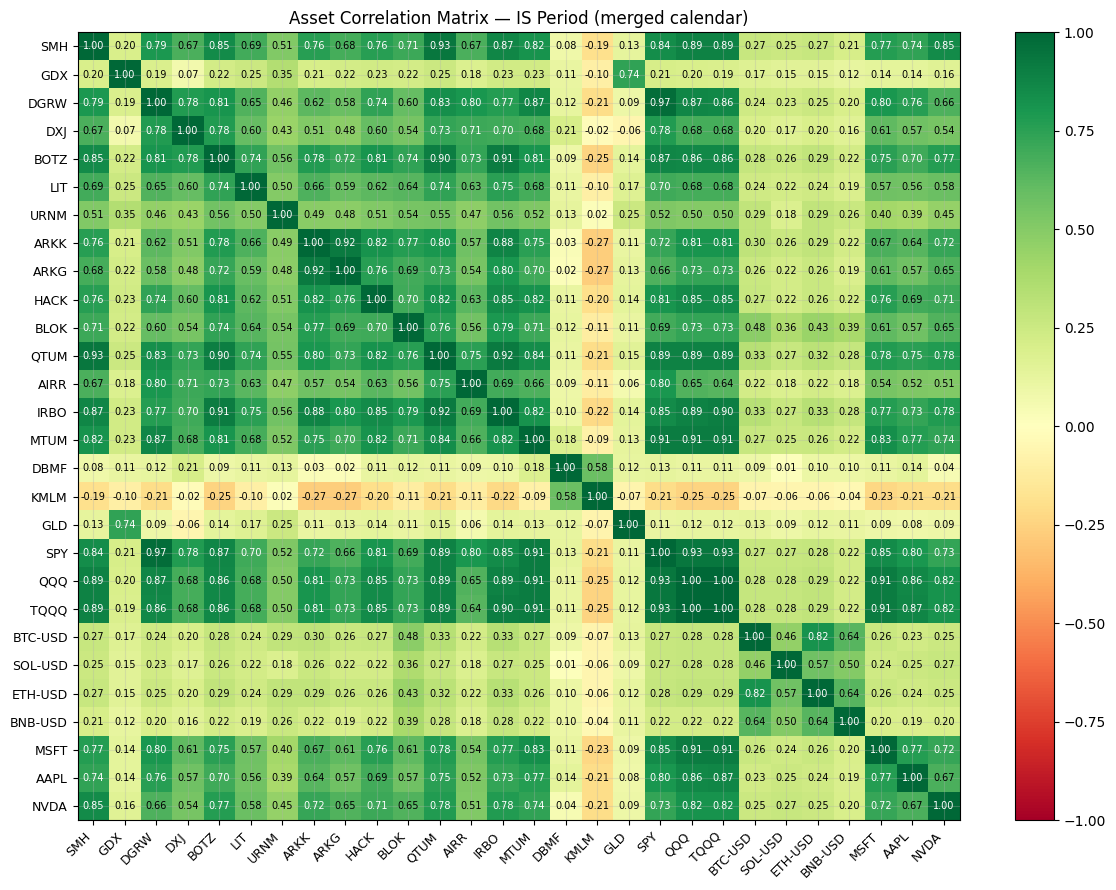

In [405]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 11 — Correlation Matrix
# ════════════════════════════════════════════════════════════════════════════
# Buy-and-hold daily returns over IS on the merged FULL_INDEX.
# Equity weekend returns = 0 (flat ffill'd close); crypto = real.
# ════════════════════════════════════════════════════════════════════════════

print('═══ Asset Correlation Matrix (IS, merged calendar) ═══\n')

bnh_rets = pd.DataFrame({
    t: all_closes[t].reindex(FULL_INDEX).pct_change()
    for t in TICKERS if t in all_closes
})[is_mask]

corr = bnh_rets.corr().round(2)
display(corr)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
ax.set_title('Asset Correlation Matrix — IS Period (merged calendar)', fontsize=12)
plt.tight_layout()
plt.show()

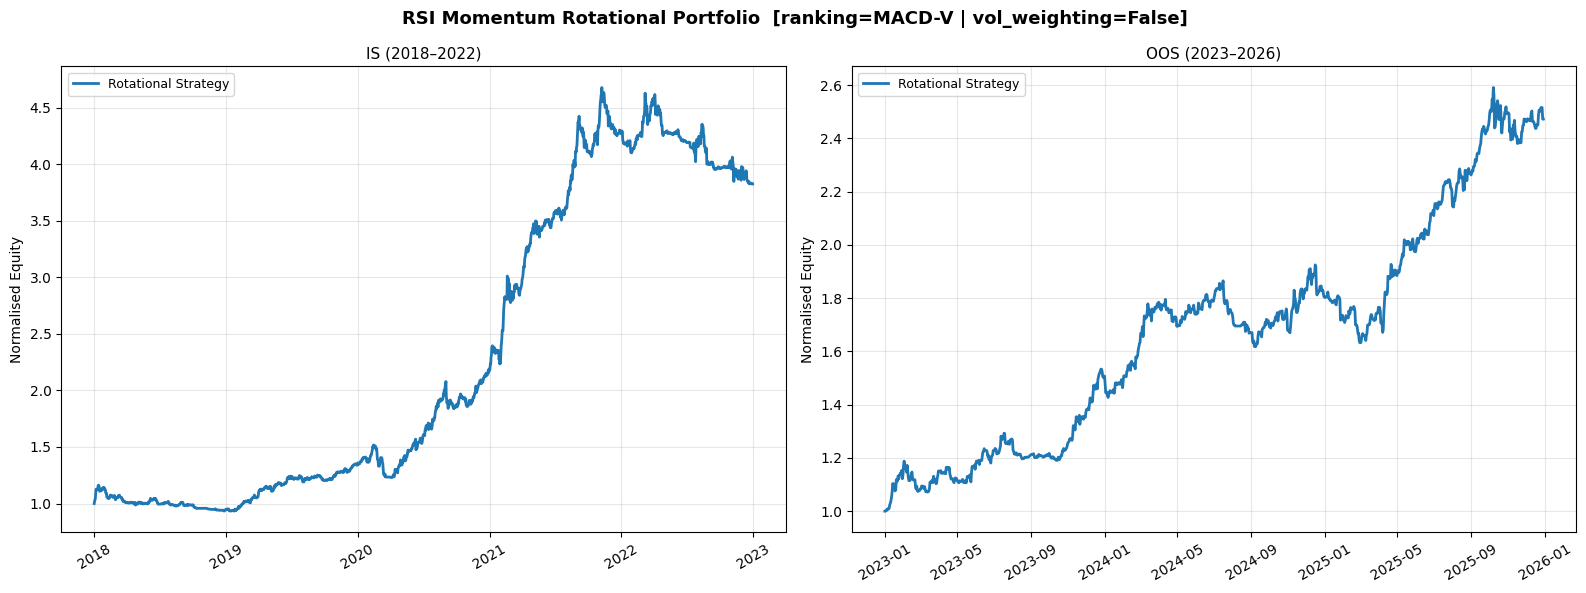

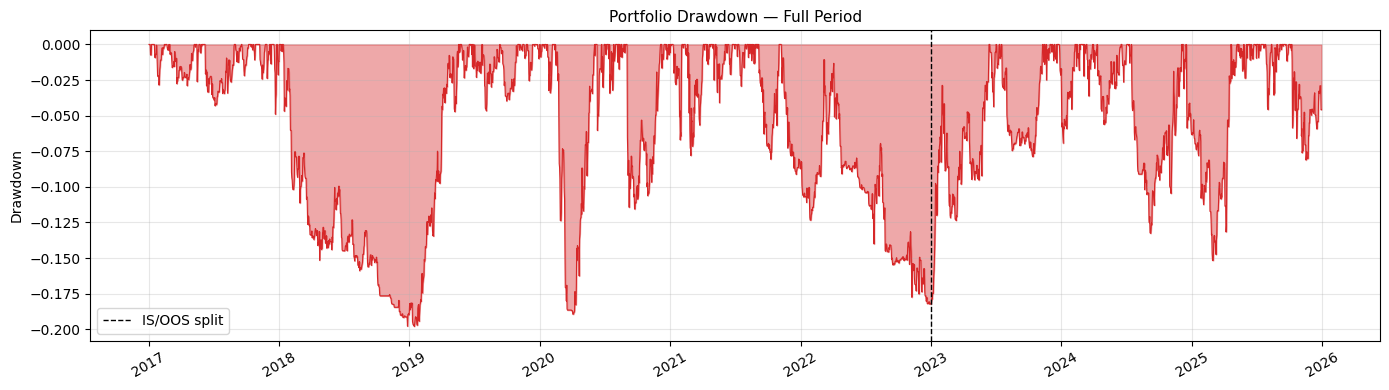

In [406]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 12 — Equity Curve & Drawdown Plots
# ════════════════════════════════════════════════════════════════════════════
# Panel 1 (IS) and Panel 2 (OOS): rotational strategy vs faded buy-and-hold.
# Panel 3: full-period drawdown with IS/OOS split line.
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'RSI Momentum Rotational Portfolio  '
    f'[ranking={rank_label} | vol_weighting={USE_VOL_WEIGHTING}]',
    fontsize=13, fontweight='bold'
)

for ax, (phase, mask, net_r, eq) in zip(axes, [
    ('IS (2018–2022)',   is_mask,  net_ret_is,  equity_is),
    ('OOS (2023–2026)', oos_mask, net_ret_oos, equity_oos),
]):
    eq_n = eq / eq.iloc[0]
    ax.plot(eq_n.index, eq_n.values, color='#1f77b4',
            linewidth=2.0, label='Rotational Strategy')

    bh_colors = plt.cm.tab10(np.linspace(0, 1, len(TICKERS)))
    for i, t in enumerate(TICKERS):
        if t not in all_closes:
            continue
        cl   = all_closes[t].reindex(eq.index)
        bh   = (1 + cl.pct_change()).cumprod()
        bh_n = bh / bh.iloc[0]
        ax.plot(bh_n.index, bh_n.values,
                color=bh_colors[i], linewidth=0.7,
                alpha=0.35, linestyle='--', label=t)

    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.tick_params(axis='x', rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1], labels[:1], fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
dd = (equity_full - equity_full.cummax()) / equity_full.cummax()
ax.fill_between(dd.index, dd.values, 0, color='#d62728', alpha=0.4)
ax.plot(dd.index, dd.values, color='#d62728', linewidth=0.8)
ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.0, label='IS/OOS split')
ax.set_title('Portfolio Drawdown — Full Period', fontsize=11)
ax.set_ylabel('Drawdown')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

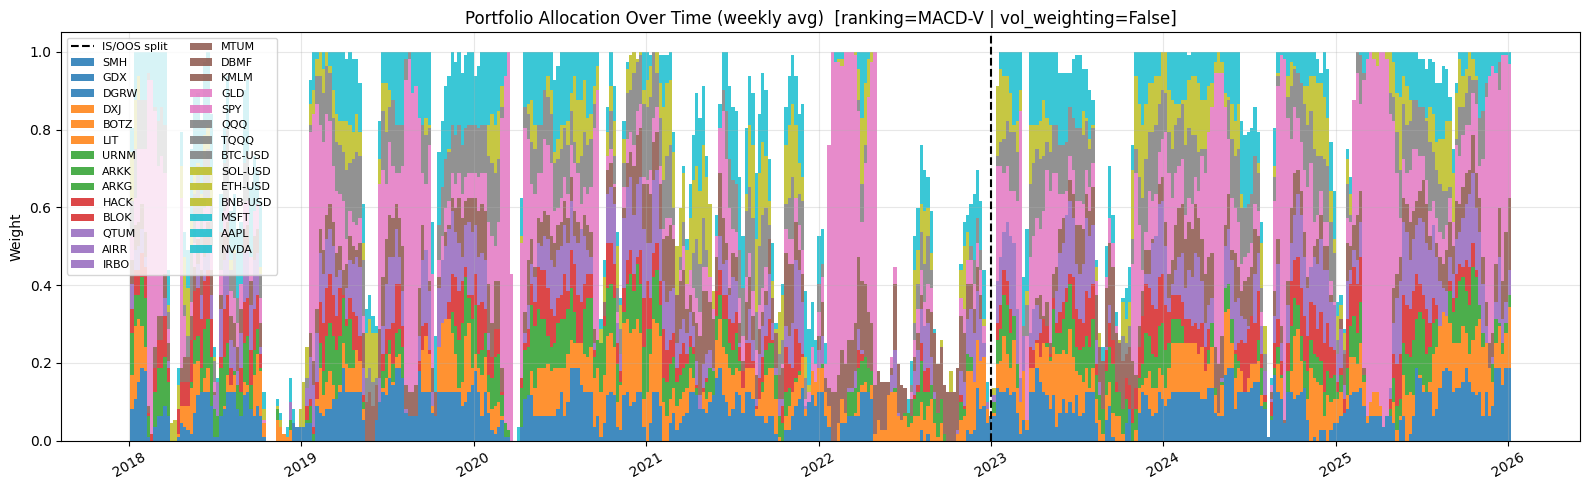


═══ Average Allocation by Asset ═══


GLD        13.6%
SPY         4.1%
MTUM        3.6%
MSFT        3.4%
QQQ         3.3%
DGRW        3.2%
SMH         3.1%
NVDA        3.0%
TQQQ        3.0%
DXJ         2.9%
AAPL        2.9%
AIRR        2.7%
BOTZ        2.5%
HACK        2.4%
ARKK        2.3%
BLOK        2.3%
DBMF        2.2%
IRBO        2.2%
BNB-USD     2.1%
QTUM        2.0%
LIT         2.0%
ARKG        1.9%
GDX         1.9%
BTC-USD     1.8%
ETH-USD     1.6%
URNM        1.5%
SOL-USD     1.2%
KMLM        0.9%
Name: Avg Weight, dtype: object


═══ Cash Allocation ═══
  Days in partial/full cash: 45.5%


In [407]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 13 — Allocation Stacked Bar Chart
# ════════════════════════════════════════════════════════════════════════════
# Weekly average weights stacked by asset from IS_START onwards.
# Vertical dashed line marks the IS/OOS boundary.
# ════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 5))

w_weekly = weights_df.resample('W').mean()
w_weekly = w_weekly.loc[w_weekly.index >= IS_START]

colors = plt.cm.tab10(np.linspace(0, 1, len(weights_df.columns)))
bottom = np.zeros(len(w_weekly))

for i, col in enumerate(weights_df.columns):
    vals = w_weekly[col].fillna(0).values
    ax.bar(w_weekly.index, vals, bottom=bottom,
           color=colors[i], label=col, width=7, alpha=0.85)
    bottom += vals

ax.axvline(pd.Timestamp(OOS_START), color='black', linestyle='--',
           linewidth=1.5, label='IS/OOS split')
ax.set_title(
    f'Portfolio Allocation Over Time (weekly avg)  '
    f'[ranking={rank_label} | vol_weighting={USE_VOL_WEIGHTING}]',
    fontsize=12
)
ax.set_ylabel('Weight')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\n═══ Average Allocation by Asset ═══')
avg_alloc = weights_df.mean().sort_values(ascending=False)
display(avg_alloc.map('{:.1%}'.format).rename('Avg Weight'))

print(f'\n═══ Cash Allocation ═══')
cash_pct = (weights_df.sum(axis=1) < 0.999).mean()
print(f'  Days in partial/full cash: {cash_pct:.1%}')

Building correlation-filtered portfolio weights...
Weight sum stats:
  Mean : 0.666
  Min  : 0.000
  Max  : 1.000
  % days fully invested : 46.0%
  % days in cash        : 2.1%

Rebalance events       : 442
Avg turnover per event : 36.5%

Correlation-filtered weights built ✓  [ranking=MACD-V | vol_weighting=False]

═══ Original vs Correlation-Filtered [ranking=MACD-V | vol_weighting=False] ═══



,CAGR,Sharpe,MaxDD,Calmar,WinRate
Label,,,,,
Original (IS),0.3081,1.6455,-0.1980,1.5557,0.4496
Original (OOS),0.3529,1.8187,-0.1517,2.3266,0.4694
Corr-Filtered (IS),0.2296,1.4392,-0.1934,1.1869,0.4617
Corr-Filtered (OOS),0.2692,1.7053,-0.0988,2.7249,0.4895


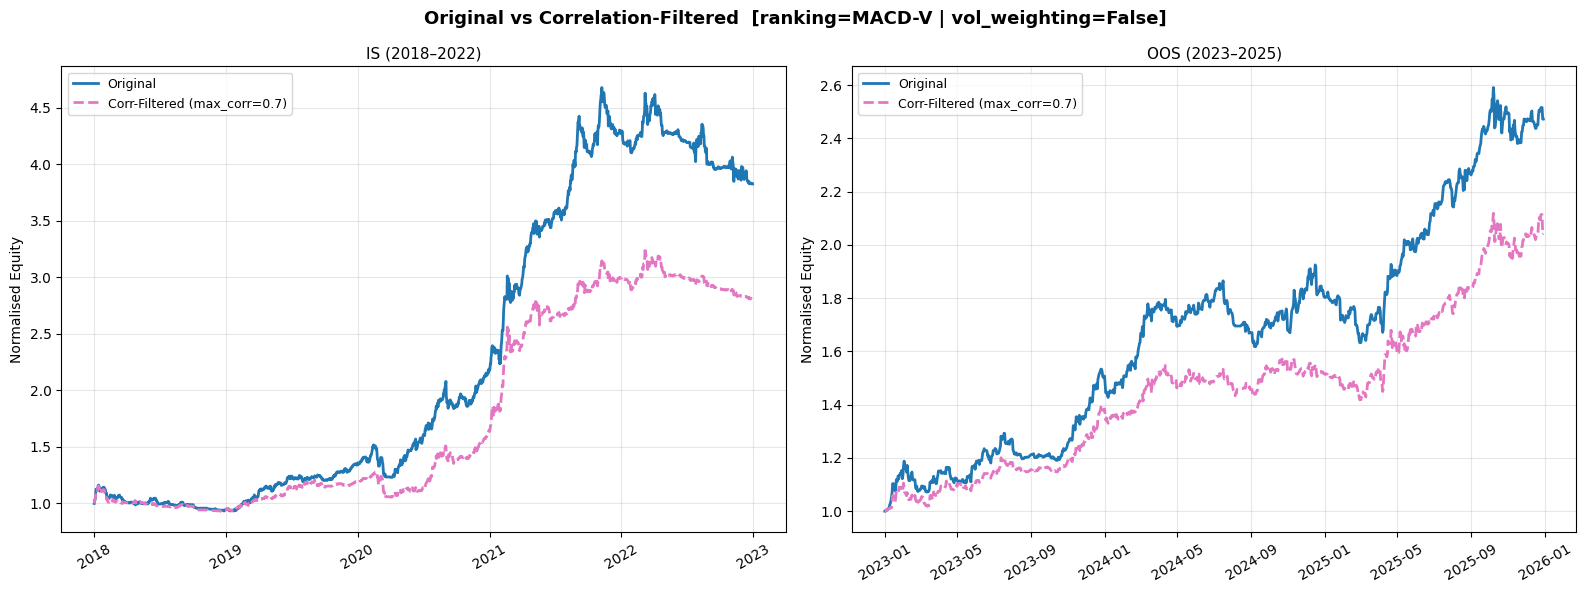

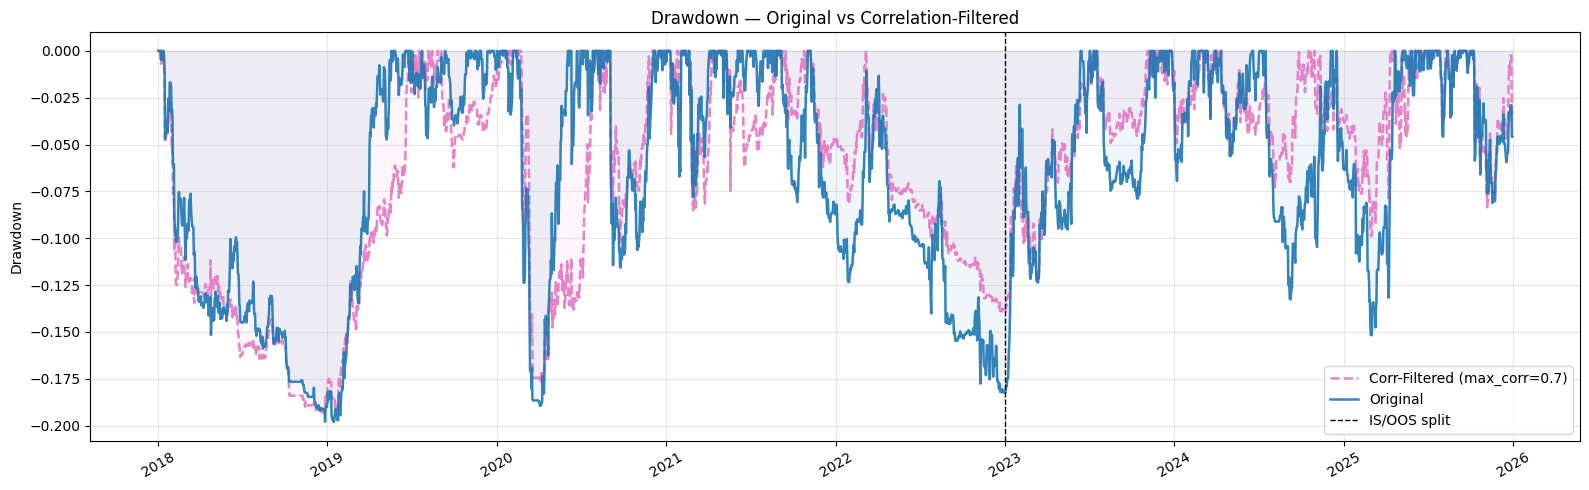

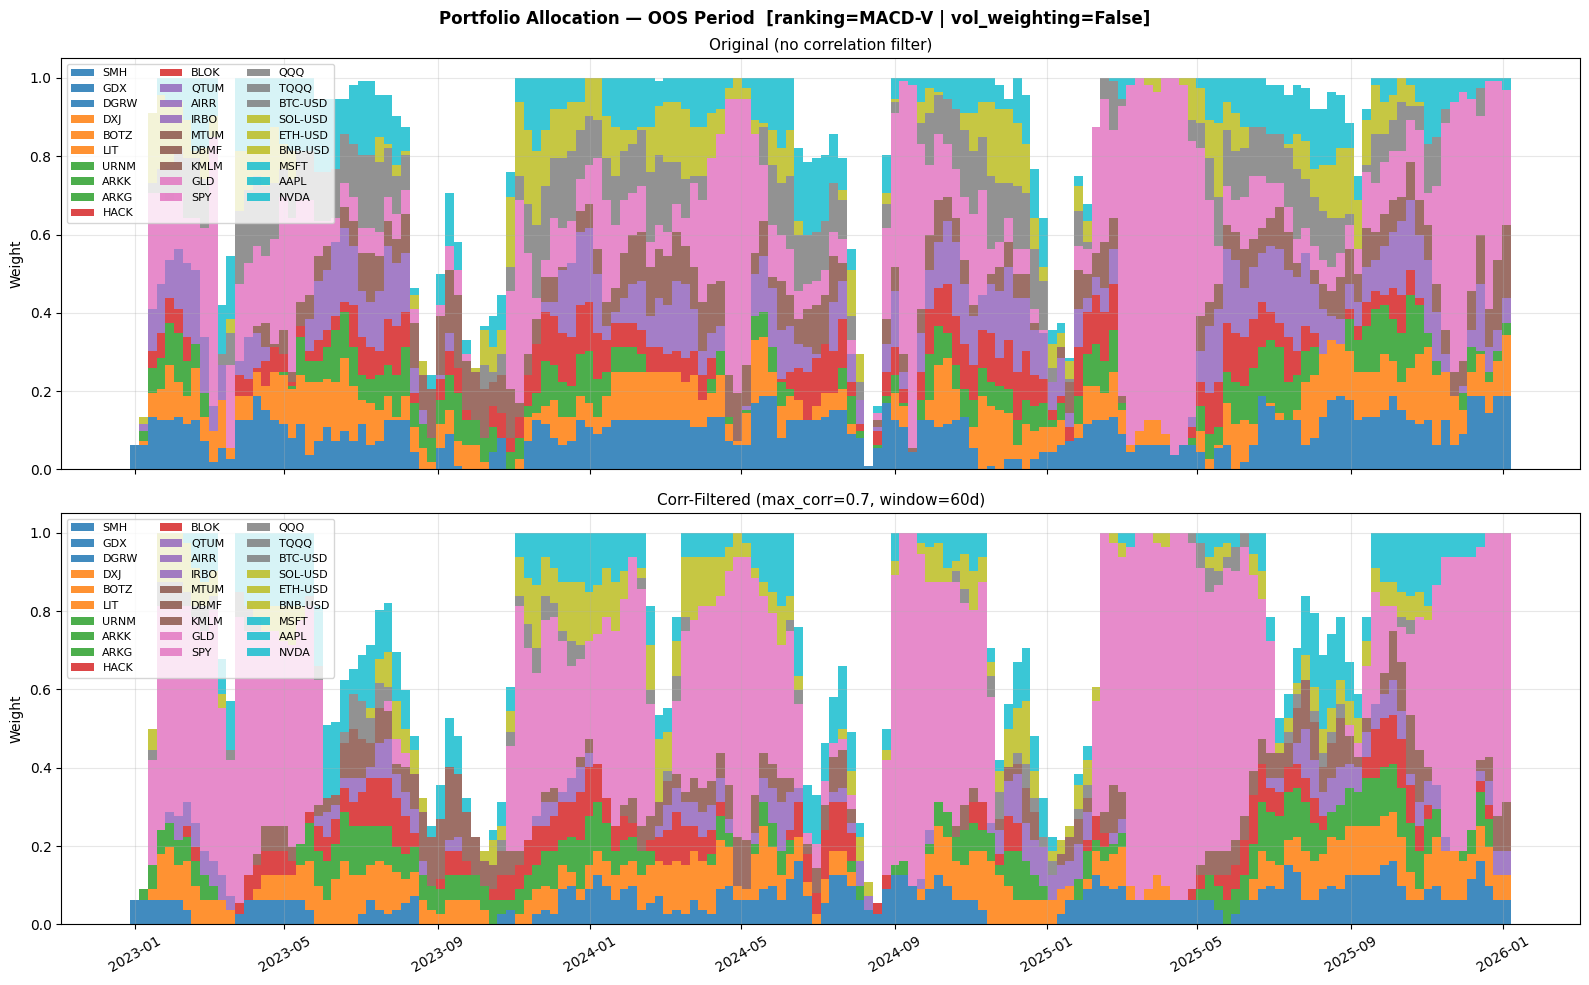


═══ Full Comparison vs SPY Buy & Hold ═══



,CAGR,Sharpe,MaxDD,Calmar,WinRate,Years
Label,,,,,,
Original (IS),0.3081,1.6455,-0.1980,1.5557,0.4496,4.9966
Original (OOS),0.3529,1.8187,-0.1517,2.3266,0.4694,2.9952
Corr-Filtered (IS),0.2296,1.4392,-0.1934,1.1869,0.4617,4.9966
Corr-Filtered (OOS),0.2692,1.7053,-0.0988,2.7249,0.4895,2.9952
SPY BnH (IS),0.0932,0.5219,-0.3372,0.2764,0.3746,4.9966
SPY BnH (OOS),0.2322,1.4388,-0.1876,1.2378,0.3936,2.9952


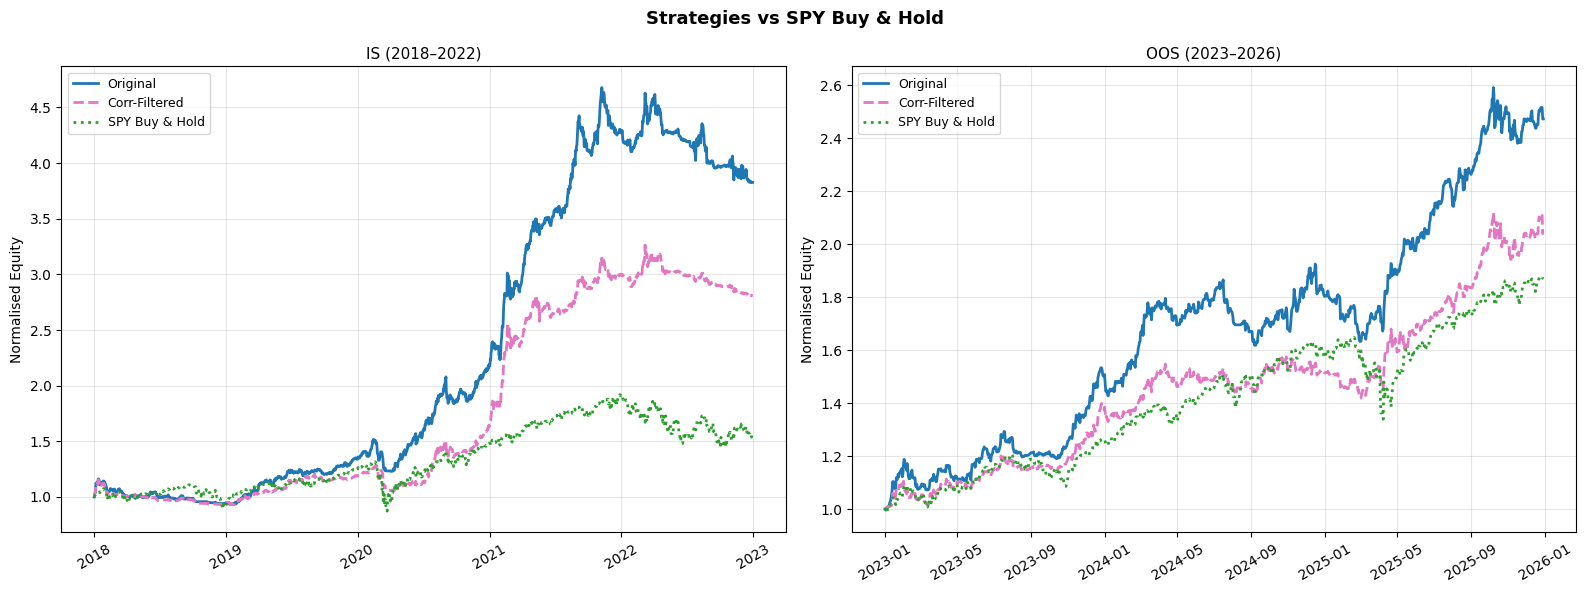

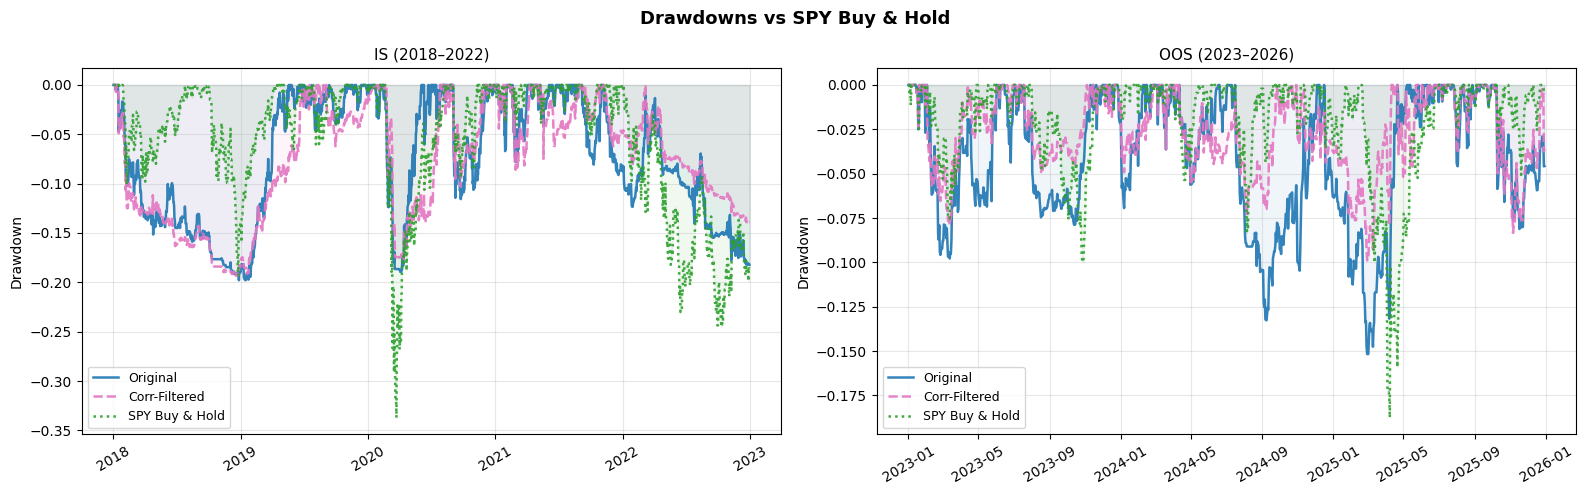

In [408]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 14 — Correlation Filter  ★ MODIFIED
# ════════════════════════════════════════════════════════════════════════════
# Selection logic is IDENTICAL to the original.
# Modification: the weight-sizing step now respects USE_VOL_WEIGHTING so the
# corr-filtered variant is consistent with the base strategy.
#
# LOOK-AHEAD GUARDS (same as original):
#   - Correlation window uses iloc[past_i - corr_window : past_i], which
#     strictly excludes today (past_i = idx_map[date]).
#   - Vol lookup reuses _vol_for_date() which applies the same past-only slice.
# ════════════════════════════════════════════════════════════════════════════



CORR_WINDOW = 60
MAX_CORR    = 0.70


def build_portfolio_weights_corr(rsi_ranks, all_positions, all_closes,
                                  top_n, safe_haven, tickers,
                                  rebalance_freq, max_corr, corr_window,
                                  use_vol_weighting=False,
                                  vol_window=20, vol_floor=1e-6):
    common_idx = rsi_ranks.index
    pos_df = pd.DataFrame({
        t: all_positions[t].reindex(common_idx, fill_value=0)
        for t in tickers if t in all_positions
    })
    rank_df = rsi_ranks.reindex(columns=pos_df.columns)

    ret_df_local = pd.DataFrame({
        t: all_closes[t].reindex(common_idx).pct_change().fillna(0)
        for t in pos_df.columns if t in all_closes
    })

    weight_per_slot = 1.0 / top_n
    weights_corr_df = pd.DataFrame(0.0, index=common_idx, columns=pos_df.columns)
    risk_universe   = [t for t in pos_df.columns if t != safe_haven]

    rebalance_dates = set(
        pd.date_range(common_idx[0], common_idx[-1], freq=rebalance_freq)
        .map(lambda d: common_idx[common_idx <= d].max()
             if len(common_idx[common_idx <= d]) > 0 else pd.NaT)
    )
    rebalance_dates.discard(pd.NaT)

    current_weights = pd.Series(0.0, index=pos_df.columns)

    # Positional index map for O(1) past-slice access — no look-ahead
    idx_map = {date: i for i, date in enumerate(common_idx)}

    for date in common_idx:
        if date in rebalance_dates:
            ranks_today = rank_df.loc[date]
            pos_today   = pos_df.loc[date]
            new_weights = pd.Series(0.0, index=pos_df.columns)

            # LOOK-AHEAD GUARD: strictly past returns for correlation.
            # idx_map[date] is today's positional index; slice excludes it.
            past_i      = idx_map[date]
            hist        = ret_df_local.iloc[max(0, past_i - corr_window) : past_i]
            corr_matrix = hist.corr()

            # Wider candidate pool so the corr screen has more to pick from
            top_ranked = ranks_today[
                ranks_today.index.isin(risk_universe) &
                (ranks_today <= top_n * 3)
            ].sort_values().index.tolist()

            eligible_risk = [t for t in top_ranked if pos_today.get(t, 0) == 1]

            # Greedy pairwise correlation screen
            selected = []
            for candidate in eligible_risk:
                if len(selected) >= top_n:
                    break
                if len(selected) == 0:
                    selected.append(candidate)
                    continue
                corrs = []
                for already_in in selected:
                    try:
                        c = abs(corr_matrix.loc[candidate, already_in])
                    except KeyError:
                        c = 0.0
                    corrs.append(c)
                if max(corrs) < max_corr:
                    selected.append(candidate)

            slots_filled = len(selected)

            if slots_filled > 0:
                if use_vol_weighting and slots_filled > 1:
                    # LOOK-AHEAD GUARD: _vol_for_date uses past_i slice only
                    vols       = _vol_for_date(ret_df_local, date,
                                               idx_map, vol_window, vol_floor)
                    inv_vols   = pd.Series(
                        {t: 1.0 / vols.get(t, vol_floor) for t in selected}
                    )
                    risk_alloc = slots_filled * weight_per_slot
                    inv_sum    = inv_vols.sum()
                    for asset in selected:
                        new_weights[asset] = inv_vols[asset] / inv_sum * risk_alloc
                else:
                    for asset in selected:
                        new_weights[asset] = weight_per_slot

            remaining = top_n - slots_filled
            if remaining > 0 and safe_haven in pos_df.columns:
                if pos_today.get(safe_haven, 0) == 1:
                    new_weights[safe_haven] = remaining * weight_per_slot

            current_weights = new_weights

        weights_corr_df.loc[date] = current_weights

    row_sums = weights_corr_df.sum(axis=1)
    assert row_sums.max() <= 1.0 + 1e-9, \
        f'Weight sum exceeded 1.0! Max = {row_sums.max():.6f}'

    return weights_corr_df


print('Building correlation-filtered portfolio weights...')
weights_corr_df = build_portfolio_weights_corr(
    rsi_ranks, all_positions, all_closes,
    TOP_N, SAFE_HAVEN, TICKERS,
    REBALANCE_FREQ, MAX_CORR, CORR_WINDOW,
    use_vol_weighting=USE_VOL_WEIGHTING,
    vol_window=VOL_WINDOW,
    vol_floor=VOL_FLOOR,
)

net_ret_corr, gross_ret_corr, costs_corr, _ = build_portfolio_returns(
    weights_corr_df, all_closes, CRYPTO_TICKERS, TQQQ_DECAY_BPS_PER_DAY
)

is_mask_c  = (net_ret_corr.index >= IS_START)  & (net_ret_corr.index <= IS_END)
oos_mask_c = (net_ret_corr.index >= OOS_START) & (net_ret_corr.index <= OOS_END)

equity_corr_full = (1 + net_ret_corr).cumprod()
equity_corr_is   = (1 + net_ret_corr[is_mask_c]).cumprod()
equity_corr_oos  = (1 + net_ret_corr[oos_mask_c]).cumprod()

weight_sums_corr = weights_corr_df.sum(axis=1)
print('Weight sum stats:')
print(f'  Mean : {weight_sums_corr.mean():.3f}')
print(f'  Min  : {weight_sums_corr.min():.3f}')
print(f'  Max  : {weight_sums_corr.max():.3f}')
print(f'  % days fully invested : {(weight_sums_corr >= 0.999).mean():.1%}')
print(f'  % days in cash        : {(weight_sums_corr < 0.001).mean():.1%}')

turnovers_corr      = weights_corr_df.diff().abs().sum(axis=1)
rebalance_days_corr = turnovers_corr[turnovers_corr > 0.001]
print(f'\nRebalance events       : {len(rebalance_days_corr)}')
print(f'Avg turnover per event : {rebalance_days_corr.mean():.1%}')
print(f'\nCorrelation-filtered weights built ✓  '
      f'[ranking={rank_label} | vol_weighting={USE_VOL_WEIGHTING}]')

# ── Metrics comparison ────────────────────────────────────────────────────────
orig_is  = full_metrics(net_ret[is_mask],         equity_is,       label='Original (IS)')
orig_oos = full_metrics(net_ret[oos_mask],         equity_oos,      label='Original (OOS)')
corr_is  = full_metrics(net_ret_corr[is_mask_c],  equity_corr_is,  label='Corr-Filtered (IS)')
corr_oos = full_metrics(net_ret_corr[oos_mask_c], equity_corr_oos, label='Corr-Filtered (OOS)')

comparison_df = pd.DataFrame([orig_is, orig_oos, corr_is, corr_oos])
print(f'\n═══ Original vs Correlation-Filtered '
      f'[ranking={rank_label} | vol_weighting={USE_VOL_WEIGHTING}] ═══\n')
display(comparison_df.set_index('Label')[['CAGR','Sharpe','MaxDD','Calmar','WinRate']])

# ── Equity curve comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Original vs Correlation-Filtered  '
    f'[ranking={rank_label} | vol_weighting={USE_VOL_WEIGHTING}]',
    fontsize=13, fontweight='bold'
)

for ax, (phase, is_m, oos_m) in zip(axes, [
    ('IS (2018–2022)',   is_mask,  is_mask_c),
    ('OOS (2023–2025)', oos_mask, oos_mask_c),
]):
    use_mask = is_m if 'IS' in phase else oos_m
    orig_eq  = (1 + net_ret[use_mask]).cumprod()
    corr_eq  = (1 + net_ret_corr[use_mask]).cumprod()
    orig_n   = orig_eq / orig_eq.iloc[0]
    corr_n   = corr_eq / corr_eq.iloc[0]
    ax.plot(orig_n.index, orig_n.values,
            color='#1f77b4', linewidth=2.0, label='Original')
    ax.plot(corr_n.index, corr_n.values,
            color='#e377c2', linewidth=2.0, linestyle='--',
            label=f'Corr-Filtered (max_corr={MAX_CORR})')
    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── Full-period drawdown overlay ──────────────────────────────────────────────
PLOT_START = pd.Timestamp(IS_START)

fig, ax = plt.subplots(figsize=(16, 5))
for eq, color, label, ls in [
    (equity_corr_full, '#e377c2', f'Corr-Filtered (max_corr={MAX_CORR})', '--'),
    (equity_full,      '#1f77b4', 'Original',                             '-'),
]:
    eq_plot = eq[eq.index >= PLOT_START]
    eq_n    = eq_plot / eq_plot.iloc[0]
    dd      = eq_n / eq_n.cummax() - 1
    ax.plot(dd.index, dd.values, color=color,
            linewidth=1.8, linestyle=ls, label=label, alpha=0.9)
    ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.07)

ax.axvline(pd.Timestamp(OOS_START), color='black',
           linestyle='--', linewidth=1.0, label='IS/OOS split')
ax.set_title('Drawdown — Original vs Correlation-Filtered', fontsize=12)
ax.set_ylabel('Drawdown')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# ── OOS allocation stacked bars — both variants ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(
    f'Portfolio Allocation — OOS Period  '
    f'[ranking={rank_label} | vol_weighting={USE_VOL_WEIGHTING}]',
    fontsize=12, fontweight='bold'
)

colors = plt.cm.tab10(np.linspace(0, 1, len(weights_df.columns)))
for ax, (wdf, title) in zip(axes, [
    (weights_df,      'Original (no correlation filter)'),
    (weights_corr_df, f'Corr-Filtered (max_corr={MAX_CORR}, window={CORR_WINDOW}d)'),
]):
    w_oos  = wdf[oos_mask].resample('W').mean()
    bottom = np.zeros(len(w_oos))
    for i, col in enumerate(wdf.columns):
        vals = w_oos[col].fillna(0).values
        ax.bar(w_oos.index, vals, bottom=bottom,
               color=colors[i], label=col, width=7, alpha=0.85)
        bottom += vals
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Weight')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── S&P 500 Buy & Hold benchmark ─────────────────────────────────────────────

spy_close  = all_closes['SPY'].reindex(FULL_INDEX).ffill()
spy_daily  = spy_close.pct_change().fillna(0)
spy_equity = (1 + spy_daily).cumprod()

spy_is_mask  = (spy_daily.index >= IS_START)  & (spy_daily.index <= IS_END)
spy_oos_mask = (spy_daily.index >= OOS_START) & (spy_daily.index <= OOS_END)

spy_eq_is  = (1 + spy_daily[spy_is_mask]).cumprod()
spy_eq_oos = (1 + spy_daily[spy_oos_mask]).cumprod()

# ── Metrics ───────────────────────────────────────────────────────────────────
m_spy_is  = full_metrics(spy_daily[spy_is_mask],  spy_eq_is,  label='SPY BnH (IS)')
m_spy_oos = full_metrics(spy_daily[spy_oos_mask], spy_eq_oos, label='SPY BnH (OOS)')

m_orig_is  = full_metrics(net_ret[is_mask],         equity_is,      label='Original (IS)')
m_orig_oos = full_metrics(net_ret[oos_mask],         equity_oos,     label='Original (OOS)')
m_corr_is  = full_metrics(net_ret_corr[is_mask_c],  equity_corr_is, label='Corr-Filtered (IS)')
m_corr_oos = full_metrics(net_ret_corr[oos_mask_c], equity_corr_oos,label='Corr-Filtered (OOS)')

print('\n═══ Full Comparison vs SPY Buy & Hold ═══\n')
display(
    pd.DataFrame([m_orig_is,  m_orig_oos,
                  m_corr_is,  m_corr_oos,
                  m_spy_is,   m_spy_oos])
    .set_index('Label')[['CAGR','Sharpe','MaxDD','Calmar','WinRate','Years']]
)

# ── Equity curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Strategies vs SPY Buy & Hold', fontsize=13, fontweight='bold')

for ax, (phase, mask_orig, mask_corr, mask_spy) in zip(axes, [
    ('IS (2018–2022)',  is_mask,  is_mask_c,  spy_is_mask),
    ('OOS (2023–2026)', oos_mask, oos_mask_c, spy_oos_mask),
]):
    for ret, mask, label, color, ls in [
        (net_ret,      mask_orig, 'Original',       '#1f77b4', '-'),
        (net_ret_corr, mask_corr, 'Corr-Filtered',  '#e377c2', '--'),
        (spy_daily,    mask_spy,  'SPY Buy & Hold',  '#2ca02c', ':'),
    ]:
        eq   = (1 + ret[mask]).cumprod()
        eq_n = eq / eq.iloc[0]
        ax.plot(eq_n.index, eq_n.values,
                color=color, linewidth=2.0, linestyle=ls, label=label)
    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Normalised Equity')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── Drawdowns ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Drawdowns vs SPY Buy & Hold', fontsize=13, fontweight='bold')

for ax, (phase, mask_orig, mask_corr, mask_spy) in zip(axes, [
    ('IS (2018–2022)',  is_mask,  is_mask_c,  spy_is_mask),
    ('OOS (2023–2026)', oos_mask, oos_mask_c, spy_oos_mask),
]):
    for ret, mask, label, color, ls in [
        (net_ret,      mask_orig, 'Original',       '#1f77b4', '-'),
        (net_ret_corr, mask_corr, 'Corr-Filtered',  '#e377c2', '--'),
        (spy_daily,    mask_spy,  'SPY Buy & Hold',  '#2ca02c', ':'),
    ]:
        eq   = (1 + ret[mask]).cumprod()
        eq_n = eq / eq.iloc[0]
        dd   = eq_n / eq_n.cummax() - 1
        ax.plot(dd.index, dd.values, color=color,
                linewidth=1.8, linestyle=ls, label=label, alpha=0.9)
        ax.fill_between(dd.index, dd.values, 0, color=color, alpha=0.07)
    ax.set_title(phase, fontsize=11)
    ax.set_ylabel('Drawdown')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()